# BIND2 Methods Paper — Figures

All plots for the methods paper. Run cells top-to-bottom; heavy data-loading cells (~1–2 min each) are marked.

## Setup

In [1]:
import json
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm, SymLogNorm

sys.path.insert(0, '/mnt/home/mlee1/vdm_bind2/src')
from bind.metrics import (
    CHANNEL_NAMES,
    radial_profile,
    batch_profiles,
    power_spectrum_2d,
    batch_power_spectra,
    power_spectrum_pylians_2d,
    batch_power_spectra_pylians,
    pixel_ks_test,
)

plt.rcParams.update({
    'font.size': 10,
    'font.family': 'serif',
    'mathtext.fontset': 'cm',
    'figure.dpi': 120,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight',
    'axes.grid': False,
})

SUITE_ROOT = Path('/mnt/home/mlee1/ceph/fm_testsuite')
SNAP = 'snap_090'
MASS_TAG = 'mass_threshold_1p000e13'
MODEL_NAME = 'fm_two_head'
BOX_SIZE = 50.0        # Mpc/h
N_PIX_FULL = 1024
PATCH_PIX = 128
PATCH_BOX = BOX_SIZE * PATCH_PIX / N_PIX_FULL   # 6.25 Mpc/h
N_PARAMS = 35

FIG_DIR = Path('paper_figures')
FIG_DIR.mkdir(exist_ok=True)

SUITES = ('CV', '1P', 'Test')
SUITE_COLORS = {'CV': 'tab:green', '1P': 'tab:blue', 'Test': 'tab:red'}
SUITE_DISPLAY = {'CV': 'CV', '1P': '1P', 'Test': 'SB35'}

_param_meta = pd.read_csv(
    '/mnt/home/mlee1/Sims/IllustrisTNG_extras/L50n512/SB35/SB35_param_minmax.csv'
)
PARAM_NAMES = {i + 1: name for i, name in enumerate(_param_meta['ParamName'])}
PARAM_LOG = {i + 1: bool(v) for i, v in enumerate(_param_meta['LogFlag'])}

PARAM_LABELS = {
    1:  r'$\Omega_m$',
    2:  r'$\sigma_8$',
    3:  r'$A_{\rm SN1}$',
    4:  r'$A_{\rm AGN1}$',
    5:  r'$A_{\rm ASN2}$',
    6:  r'$A_{\rm AGN2}$',
}
for i in range(7, N_PARAMS + 1):
    PARAM_LABELS[i] = PARAM_NAMES.get(i, f'p{i}')

print('Channels :', CHANNEL_NAMES)
print('Box      :', BOX_SIZE, 'Mpc/h  |  patch box:', PATCH_BOX, 'Mpc/h')
print('Fig dir  :', FIG_DIR.resolve())


def save_fig(fig, name: str, ext=('pdf', 'png')):
    """Save a figure under FIG_DIR with the given base name, in both formats."""
    for e in ext:
        out = FIG_DIR / f'{name}.{e}'
        fig.savefig(out)
        print(f'  wrote {out}')
import scienceplots
plt.style.use(['science','notebook'])

Channels : ['DM_hydro', 'Gas', 'Stars']
Box      : 50.0 Mpc/h  |  patch box: 6.25 Mpc/h
Fig dir  : /mnt/home/mlee1/vdm_bind2/examples/paper_figures


## Simulation Discovery

In [2]:
def sim_record(sim_dir: Path, suite_name: str) -> dict:
    snap = sim_dir / SNAP
    mass = snap / MASS_TAG
    model = mass / MODEL_NAME
    rec = {
        'suite': suite_name,
        'sim_id': sim_dir.name,
        'sim_dir': sim_dir,
        'full_maps':     snap / 'full_maps.npz',
        'halo_catalog':  mass / 'halo_catalog.npz',
        'generated':     model / 'generated_halos.npz',
        'composite':     model / 'composite.npz',
        'summary':       model / 'summary.json',
    }
    rec['available'] = all(
        rec[k].exists() for k in ('full_maps', 'halo_catalog', 'generated', 'composite')
    )
    return rec


def discover_sims(suites=SUITES) -> pd.DataFrame:
    recs = []
    for suite in suites:
        root = SUITE_ROOT / suite
        if not root.exists():
            print(f'[skip] {root} missing')
            continue
        for sd in sorted(root.iterdir()):
            if sd.is_dir():
                recs.append(sim_record(sd, suite))
    df = pd.DataFrame(recs)
    return df


sims_all = discover_sims()
print('Discovered:')
print(sims_all.groupby('suite')['available'].agg(['sum', 'count']))

sims = sims_all[sims_all['available']].reset_index(drop=True)
cv_sims   = sims[sims['suite'] == 'CV'].reset_index(drop=True)
oneP_sims = sims[sims['suite'] == '1P'].reset_index(drop=True)
test_sims = sims[sims['suite'] == 'Test'].reset_index(drop=True)
print(f'\nAvailable: CV={len(cv_sims)}  1P={len(oneP_sims)}  Test={len(test_sims)}')


Discovered:
       sum  count
suite            
1P     139    141
CV      27     27
Test   102    102

Available: CV=27  1P=139  Test=102


## Data Loading Utilities

In [3]:
def extract_patch(field_2d, cx_pix, cy_pix, size=PATCH_PIX):
    """Periodic size×size cutout of a 2D field centred on (cx_pix, cy_pix)."""
    n = field_2d.shape[0]
    half = size // 2
    ix = (cx_pix - half + np.arange(size)) % n
    iy = (cy_pix - half + np.arange(size)) % n
    return field_2d[np.ix_(ix, iy)]


def centers_to_pixels(centers_mpc):
    """Convert (N, 2) halo centres in Mpc/h to integer pixel coords on 1024 grid."""
    ppm = N_PIX_FULL / BOX_SIZE
    return (np.asarray(centers_mpc) * ppm).astype(np.int64) % N_PIX_FULL


def load_full_maps(rec) -> dict:
    d = np.load(rec['full_maps'])
    return {'dmo_fullbox': d['dmo_fullbox'], 'truth_maps': d['truth_maps']}


def load_catalog(rec) -> dict:
    d = np.load(rec['halo_catalog'])
    out = {'centers': d['centers'], 'masses': d['masses']}
    if 'params' in d.files:
        out['params'] = d['params']
    return out


def load_generated(rec) -> np.ndarray:
    """(N, 3, 128, 128) generated halo patches."""
    return np.load(rec['generated'])['generated']


def load_composite(rec) -> dict:
    d = np.load(rec['composite'])
    return {k: d[k] for k in d.files}


def load_summary(rec) -> dict:
    if not rec['summary'].exists():
        return {}
    with open(rec['summary']) as f:
        return json.load(f)


def halo_patches(rec):
    """Return (truth_patches, gen_patches, masses, centers, params) for one sim.

    truth_patches are extracted from `truth_maps` at the same pixel centres
    the pipeline used during generation.
    """
    fm = load_full_maps(rec)
    cat = load_catalog(rec)
    gen = load_generated(rec)

    centers_pix = centers_to_pixels(cat['centers'])
    n = len(centers_pix)
    truth = np.zeros((n, 3, PATCH_PIX, PATCH_PIX), dtype=np.float32)
    for i, (cx, cy) in enumerate(centers_pix):
        for c in range(3):
            truth[i, c] = extract_patch(fm['truth_maps'][c], cx, cy)
    return truth, gen, cat['masses'], cat['centers'], cat.get('params')


In [4]:
def per_halo_masses(rec):
    """Return per-halo patch-integrated masses (N, 3) for truth and gen, plus halo_mass.

    Truth mass is from an extracted 128×128 patch of `truth_maps` centred on
    the halo; gen mass is the sum of the corresponding generated patch.
    """
    truth, gen, masses, *_ = halo_patches(rec)
    truth_m = truth.sum(axis=(2, 3))
    gen_m = gen.sum(axis=(2, 3))
    return truth_m.astype(np.float64), gen_m.astype(np.float64), np.asarray(masses, np.float64)


# -------- Stars-fix sanity check on CV --------
def _stars_fix_sanity(n_sims=5):
    ratios = []
    use = cv_sims.to_dict('records')[:n_sims]
    for rec in use:
        tm, gm, _ = per_halo_masses(rec)
        with np.errstate(divide='ignore', invalid='ignore'):
            r = tm / gm
        ratios.append(r)
    ratios = np.vstack(ratios)
    med = np.nanmedian(ratios, axis=0)
    print('CV median(m_truth / m_gen) per channel (expect ≈ 1.0 after Stars fix):')
    for c, name in enumerate(CHANNEL_NAMES):
        ok = '✓' if abs(med[c] - 1.0) < 0.1 else '⚠'
        print(f'  {ok} {name:>9s}: {med[c]:.4f}')

_stars_fix_sanity()


CV median(m_truth / m_gen) per channel (expect ≈ 1.0 after Stars fix):
  ✓  DM_hydro: 1.0010
  ✓       Gas: 1.0073
  ✓     Stars: 0.9568


## Fig 1 · Full-Box Showcase

  wrote paper_figures/fig1_showcase.pdf
  wrote paper_figures/fig1_showcase.png


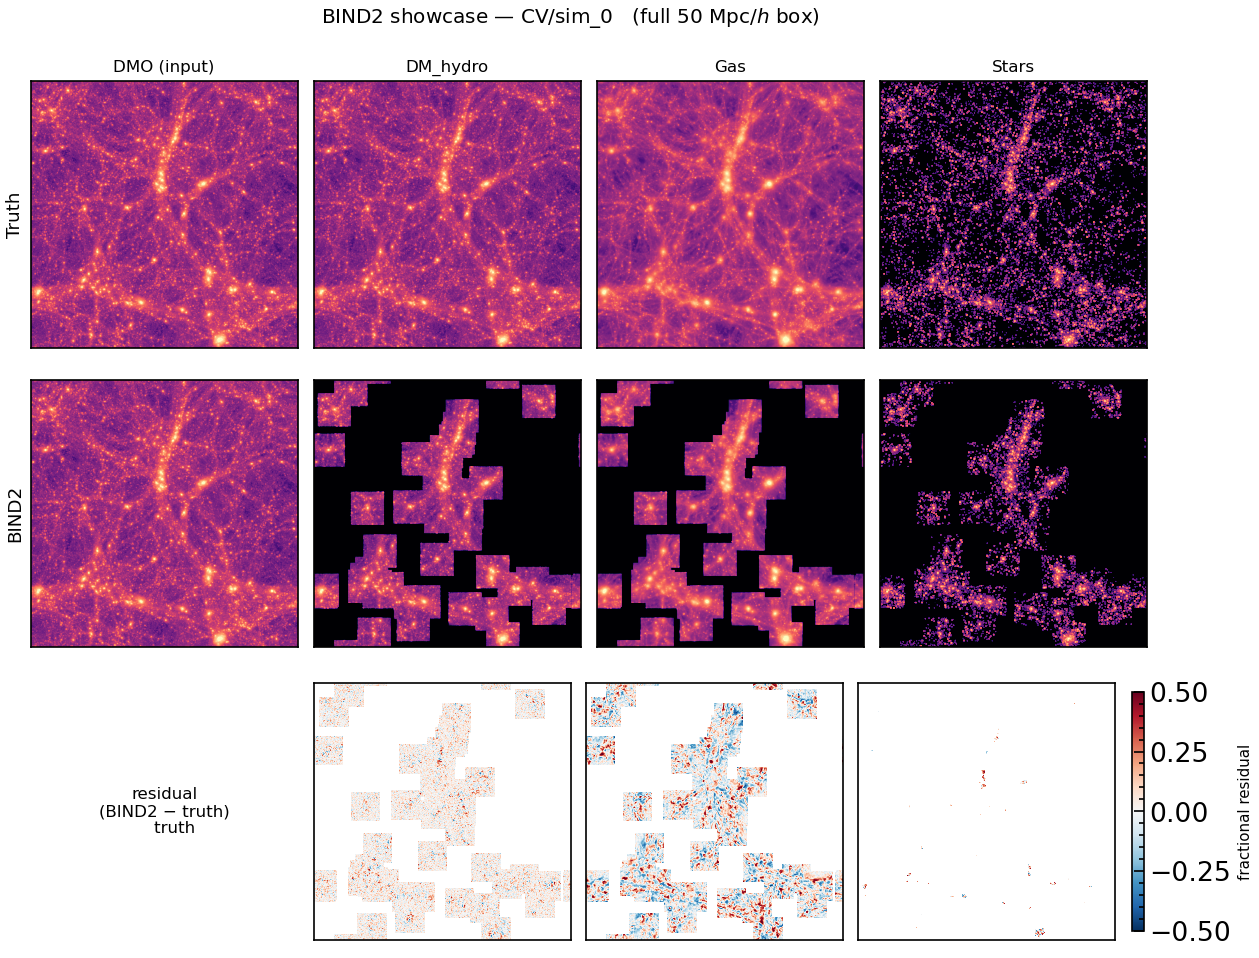

In [5]:
def _pick_busy_window(centers_mpc, masses, window_mpc=15.0):
    """Pick a top-left (x0, y0) window that contains the most halo mass."""
    if len(centers_mpc) == 0:
        return (0.0, 0.0)
    # Greedy: around the most massive halo, offset so it's centered
    imax = int(np.argmax(masses))
    cx, cy = centers_mpc[imax]
    x0 = (cx - window_mpc / 2) % BOX_SIZE
    y0 = (cy - window_mpc / 2) % BOX_SIZE
    return float(x0), float(y0)


def _crop_periodic(field_2d, x0_mpc, y0_mpc, window_mpc):
    """Periodic crop of a 1024² map to a window_mpc × window_mpc region."""
    ppm = N_PIX_FULL / BOX_SIZE
    i0 = int(round(x0_mpc * ppm))
    j0 = int(round(y0_mpc * ppm))
    n = int(round(window_mpc * ppm))
    ix = (i0 + np.arange(n)) % N_PIX_FULL
    iy = (j0 + np.arange(n)) % N_PIX_FULL
    return field_2d[np.ix_(ix, iy)]


def fig1_showcase(rec=None, cmap_field='magma',
                  cmap_resid='RdBu_r', resid_clip=0.5, save=True):
    if rec is None:
        rec = cv_sims.iloc[0].to_dict()
    fm = load_full_maps(rec)
    comp = load_composite(rec)

    dmo = fm['dmo_fullbox']
    truth = fm['truth_maps']          # (3, N, N) — full-box hydro truth
    hydro = comp['hydro_canvas']      # (3, N, N) — BIND2 predictions in cutout regions only

    fig = plt.figure(figsize=(12, 9.5))
    gs = fig.add_gridspec(3, 4, hspace=0.06, wspace=0.06)

    def _field_imshow(ax, img, title=None, linthresh=None, vmin=None, vmax=None):
        pos = img[img > 0]
        vmax = vmax if vmax is not None else np.quantile(pos, 0.999)
        vmin = vmin if vmin is not None else max(np.quantile(pos, 0.05), 1e-8)
        if linthresh is None:
            linthresh = max(vmin, 1e-6)
        norm = SymLogNorm(linthresh=linthresh, vmin=0.0, vmax=vmax, base=10)
        im = ax.imshow(img, origin='lower', cmap=cmap_field, norm=norm)
        ax.set_xticks([]); ax.set_yticks([])
        if title:
            ax.set_title(title, fontsize=10)
        return im

    ch_vmax = []
    for c in range(3):
        pos = np.concatenate([truth[c].ravel(), hydro[c].ravel()])
        pos = pos[pos > 0]
        ch_vmax.append(np.quantile(pos, 0.999))

    # Row 1 — truth
    _field_imshow(fig.add_subplot(gs[0, 0]), dmo, title='DMO (input)')
    fig.axes[-1].set_ylabel('Truth', fontsize=11)
    for c in range(3):
        _field_imshow(fig.add_subplot(gs[0, c + 1]), truth[c],
                      title=CHANNEL_NAMES[c], vmax=ch_vmax[c])

    # Row 2 — BIND2
    _field_imshow(fig.add_subplot(gs[1, 0]), dmo)
    fig.axes[-1].set_ylabel('BIND2', fontsize=11)
    for c in range(3):
        _field_imshow(fig.add_subplot(gs[1, c + 1]), hydro[c], vmax=ch_vmax[c])

    # Row 3 — fractional residual (within cutout footprints only)
    ax20 = fig.add_subplot(gs[2, 0]); ax20.axis('off')
    ax20.text(0.5, 0.5, 'residual\n(BIND2 − truth)\n    truth',
              ha='center', va='center', fontsize=10, transform=ax20.transAxes)
    last_im = None
    for c in range(3):
        ax = fig.add_subplot(gs[2, c + 1])
        with np.errstate(divide='ignore', invalid='ignore'):
            resid = np.where((truth[c] > 0) & (hydro[c] > 0),
                             (hydro[c] - truth[c]) / truth[c], np.nan)
        resid = np.clip(resid, -resid_clip, resid_clip)
        last_im = ax.imshow(resid, origin='lower', cmap=cmap_resid,
                            vmin=-resid_clip, vmax=resid_clip)
        ax.set_xticks([]); ax.set_yticks([])

    cbar = fig.colorbar(last_im, ax=fig.axes[-3:], fraction=0.018, pad=0.02,
                        location='right', shrink=0.85)
    cbar.set_label('fractional residual', fontsize=9)

    fig.suptitle(
        f'BIND2 showcase — {rec["suite"]}/{rec["sim_id"]}'
        f'   (full 50 Mpc$/h$ box)',
        y=0.94, fontsize=12,
    )
    if save:
        save_fig(fig, 'fig1_showcase')
    return fig


fig = fig1_showcase()
plt.show()


## Per-Halo Mass Analysis

Build aperture mass table, then plot scatter + error distributions (Figs 2a & 2b). *~1–2 min*

In [6]:
# ---- Aperture geometry for R_vir sums ----
_RHO_CRIT_AP  = 2.775e11                    # M_sun/h per (Mpc/h)^3
_MPC_PER_PIX_AP = PATCH_BOX / PATCH_PIX     # Mpc/h per patch pixel
_gg_ap   = np.mgrid[:PATCH_PIX, :PATCH_PIX] - PATCH_PIX / 2   # (2, 128, 128)
_RR_PIX_AP = np.sqrt(_gg_ap[0]**2 + _gg_ap[1]**2)             # (128, 128)

def _r200c_pix(m200c_msunh):
    """R200c in patch pixels for a scalar or array M200c [M_sun/h]."""
    r_mpc = (3.0 * np.asarray(m200c_msunh) / (4.0 * np.pi * 200.0 * _RHO_CRIT_AP)) ** (1.0 / 3.0)
    return r_mpc / _MPC_PER_PIX_AP


def collect_halo_mass_table(sims_df):
    """Per-halo patch-integrated masses: full 128×128 patch AND within R200c aperture.

    Returns a long-form DataFrame with columns:
      suite, sim_id, halo_mass,
      truth_{ch}, gen_{ch}            (full patch, ch in DM_hydro/Gas/Stars)
      truth_{ch}_rvir, gen_{ch}_rvir  (R200c aperture)
    """
    rows = []
    for rec in sims_df.to_dict('records'):
        try:
            truth, gen, masses, *_ = halo_patches(rec)
        except Exception as exc:
            print(f'[skip] {rec["suite"]}/{rec["sim_id"]}: {exc}')
            continue
        n = len(masses)
        # Full-patch sums
        tm_full = truth.sum(axis=(2, 3)).astype(np.float64)   # (N, 3)
        gm_full = gen.sum(axis=(2, 3)).astype(np.float64)
        # R200c aperture sums
        r_pix_arr = _r200c_pix(masses)
        tm_rv = np.zeros((n, 3), dtype=np.float64)
        gm_rv = np.zeros((n, 3), dtype=np.float64)
        for i in range(n):
            mask = _RR_PIX_AP < r_pix_arr[i]
            for c in range(3):
                tm_rv[i, c] = np.maximum(truth[i, c], 0.0)[mask].sum()
                gm_rv[i, c] = np.maximum(gen[i, c], 0.0)[mask].sum()
        for i in range(n):
            rows.append({
                'suite':   rec['suite'],
                'sim_id':  rec['sim_id'],
                'halo_mass': float(masses[i]),
                # full patch
                'truth_DM_hydro': tm_full[i, 0], 'gen_DM_hydro': gm_full[i, 0],
                'truth_Gas':      tm_full[i, 1], 'gen_Gas':      gm_full[i, 1],
                'truth_Stars':    tm_full[i, 2], 'gen_Stars':    gm_full[i, 2],
                # R200c aperture
                'truth_DM_hydro_rvir': tm_rv[i, 0], 'gen_DM_hydro_rvir': gm_rv[i, 0],
                'truth_Gas_rvir':      tm_rv[i, 1], 'gen_Gas_rvir':      gm_rv[i, 1],
                'truth_Stars_rvir':    tm_rv[i, 2], 'gen_Stars_rvir':    gm_rv[i, 2],
            })
    return pd.DataFrame(rows)


print('Building per-halo mass table across all suites (this takes ~1–2 min)...')
halo_tbl = collect_halo_mass_table(sims)
print(f'Halos total: {len(halo_tbl)}')
print(halo_tbl.groupby('suite').size())


Building per-halo mass table across all suites (this takes ~1–2 min)...
Halos total: 12249
suite
1P      6823
CV      1154
Test    4272
dtype: int64


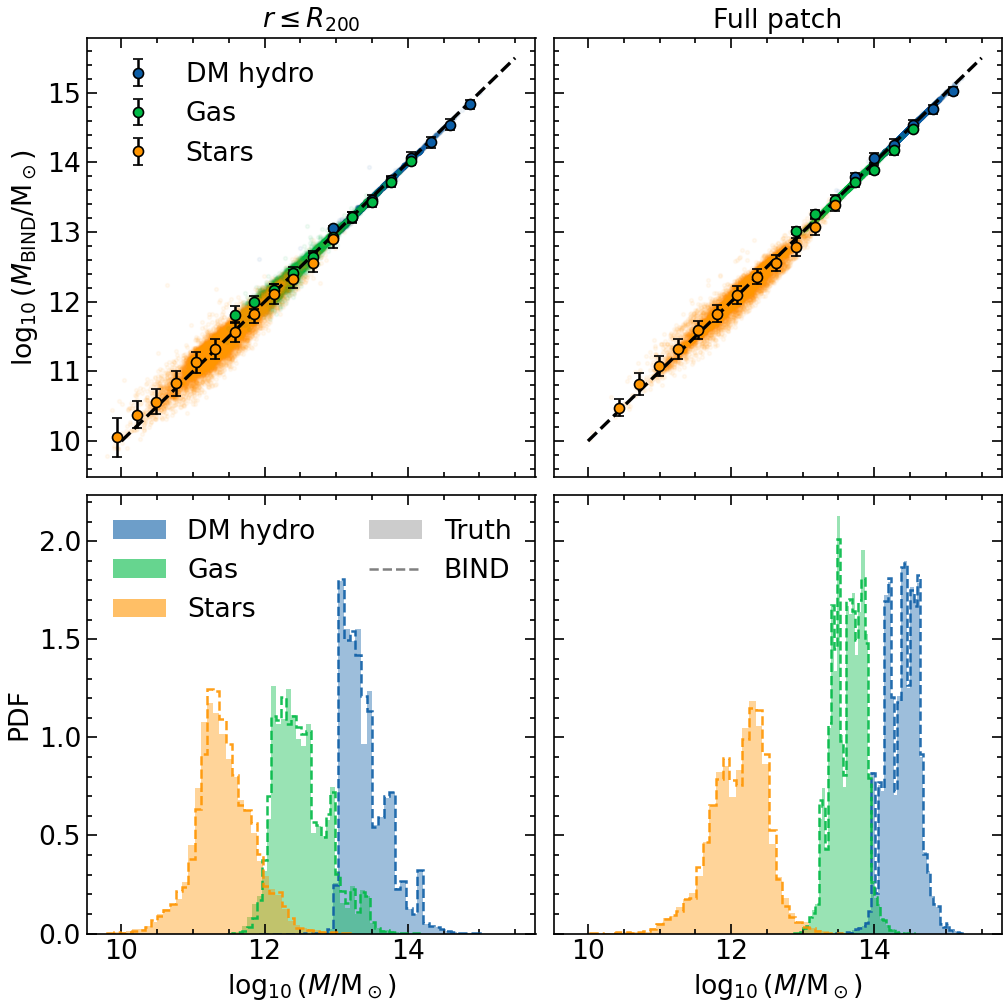

In [ ]:
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

panel_fields = [
    [
        ('truth_DM_hydro_rvir', 'gen_DM_hydro_rvir'),
        ('truth_Gas_rvir',      'gen_Gas_rvir'),
        ('truth_Stars_rvir',    'gen_Stars_rvir'),
    ],
    [
        ('truth_DM_hydro', 'gen_DM_hydro'),
        ('truth_Gas',      'gen_Gas'),
        ('truth_Stars',    'gen_Stars'),
    ],
]
titles  = [r'$r \leq R_{200}$', 'Full patch']
colors  = ['C0', 'C1', 'C2']
labels  = ['DM hydro', 'Gas', 'Stars']

fig, axes = plt.subplots(2, 2, figsize=(8.6, 4.3*2))

# Share x across all 4 panels
for ax in axes.flat[1:]:
    ax.sharex(axes[0, 0])

# Share y within each row (across columns)
axes[0, 1].sharey(axes[0, 0])
axes[1, 1].sharey(axes[1, 0])

for col, (fields, title) in enumerate(zip(panel_fields, titles)):
    valid_mask = np.ones(len(halo_tbl), dtype=bool)
    for t, g in fields:
        valid_mask &= (halo_tbl[t] > 0) & (halo_tbl[g] > 0)
    tbl = halo_tbl[valid_mask]

    # ── row 0: scatter + binned errorbars ──────────────────────────────
    ax = axes[0, col]
    bins = np.linspace(
        min(np.log10(tbl[t]).min() for t, _ in fields),
        max(np.log10(tbl[t]).max() for t, _ in fields),
        20,
    )
    bin_centers = 0.5 * (bins[:-1] + bins[1:])

    for (truth_col, gen_col), color, label in zip(fields, colors, labels):
        x = np.log10(tbl[truth_col])
        y = np.log10(tbl[gen_col])

        ax.scatter(x, y, s=5, alpha=0.05, color=color, rasterized=True)

        bin_idx = np.digitize(x, bins) - 1
        bin_mean, bin_std, bin_cx = [], [], []
        for i in range(len(bins) - 1):
            m = bin_idx == i
            if m.sum() < 5:
                continue
            bin_mean.append(np.median(y[m]))
            bin_std.append(np.std(y[m]))
            bin_cx.append(bin_centers[i])

        ax.errorbar(bin_cx, bin_mean, yerr=bin_std,
                    fmt='o', ms=6, color=color, label=label,
                    capsize=3, lw=1.5, zorder=5, mec='k', ecolor='k')

    ax.plot(np.linspace(10, 15.5, 100), np.linspace(10, 15.5, 100), 'k--')
    ax.set_title(title)
    if col == 0:
        ax.set_ylabel(r'$\log_{10}(M_{\rm BIND} / {\rm M}_\odot)$')
        ax.legend()
    else:
        plt.setp(ax.get_yticklabels(), visible=False)

    # ── row 1: distribution histograms ────────────────────────────────
    ax = axes[1, col]
    for (truth_col, gen_col), color, label in zip(fields, colors, labels):
        x_true = np.log10(tbl[truth_col])
        x_gen  = np.log10(tbl[gen_col])
        hbins  = np.linspace(x_true.min(), x_true.max(), 40)

        ax.hist(x_true, bins=hbins, color=color, alpha=0.4,
                density=True, histtype='stepfilled', label=label)
        ax.hist(x_gen,  bins=hbins, color=color, alpha=0.9,
                density=True, histtype='step', linestyle='--', lw=1.5)

    ax.set_xlabel(r'$\log_{10}(M / {\rm M}_\odot)$')
    if col == 0:
        ax.set_ylabel('PDF')
        legend_handles = (
            [Patch(facecolor=c, alpha=0.6, label=l) for c, l in zip(colors, labels)]
            + [
                Patch(facecolor='gray', alpha=0.4, label='Truth'),
                Line2D([0], [0], color='gray', lw=1.5, linestyle='--', label='BIND'),
            ]
        )
        ax.legend(handles=legend_handles, ncols=2)
    else:
        plt.setp(ax.get_yticklabels(), visible=False)

# x-axis labels only on bottom row
for ax in axes[0]:
    plt.setp(ax.get_xticklabels(), visible=False)

plt.tight_layout()
plt.savefig('paper_figures/fig2_mass_comparison.pdf', dpi=300)
plt.show()


  wrote paper_figures/fig_mass_error.pdf
  wrote paper_figures/fig_mass_error.png


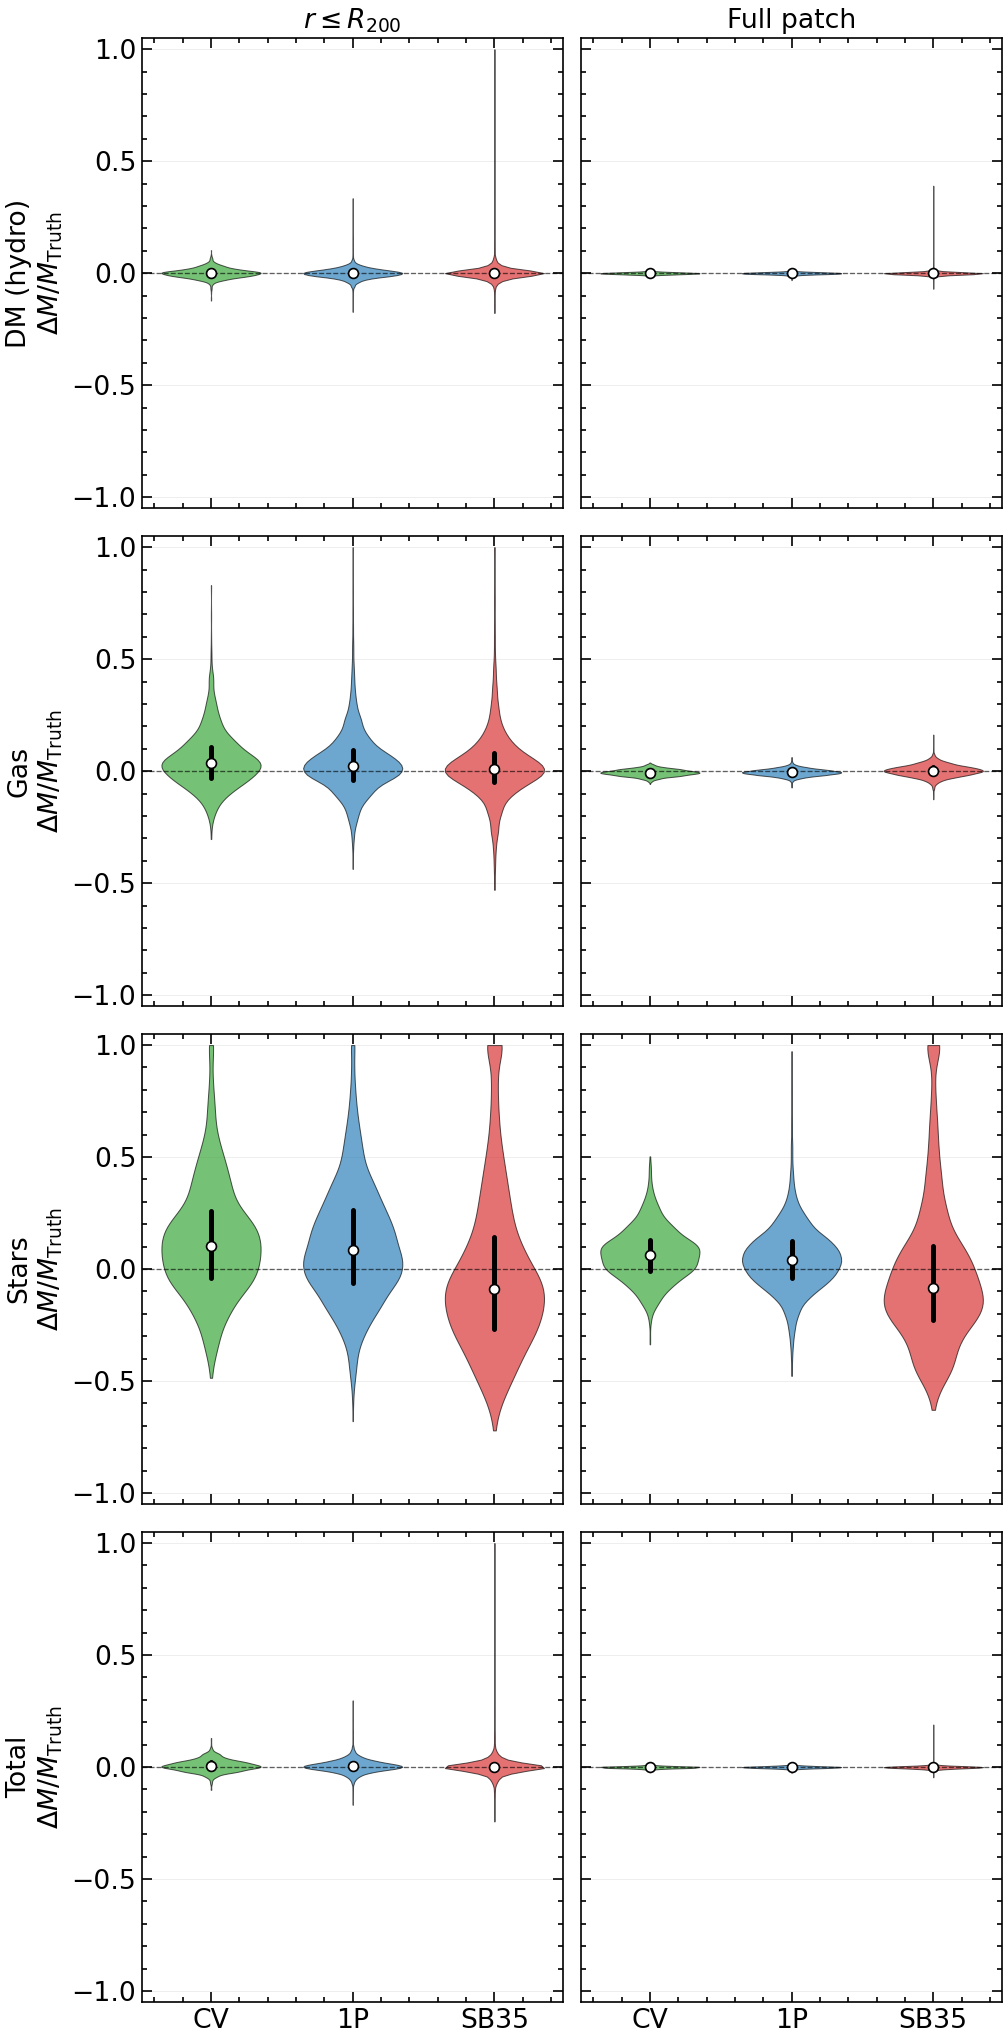

In [8]:
def fig2_mass_error(tbl, resid_lim=1.0, save=True):
    suites = list(SUITES)
    col_keys   = ['DM_hydro', 'Gas', 'Stars', 'Total']
    col_titles = ['DM (hydro)', 'Gas', 'Stars', 'Total']
    row_suffixes = ['_rvir', '']
    row_titles   = [r'$r\leq R_\mathrm{200}$', 'Full patch']

    fig, axes = plt.subplots(4, 2, figsize=(8.6, 4.3 * 4), sharex=True, sharey=True)

    for col, (suffix, col_title) in enumerate(zip(row_suffixes, row_titles)):
        for row, (ch, ch_title) in enumerate(zip(col_keys, col_titles)):
            ax = axes[row, col]

            data_per_suite = []
            for s in suites:
                sub = tbl[tbl['suite'] == s]
                if ch == 'Total':
                    t = (sub[f'truth_DM_hydro{suffix}']
                         + sub[f'truth_Gas{suffix}']
                         + sub[f'truth_Stars{suffix}']).to_numpy()
                    g = (sub[f'gen_DM_hydro{suffix}']
                         + sub[f'gen_Gas{suffix}']
                         + sub[f'gen_Stars{suffix}']).to_numpy()
                else:
                    t = sub[f'truth_{ch}{suffix}'].to_numpy()
                    g = sub[f'gen_{ch}{suffix}'].to_numpy()
                with np.errstate(divide='ignore', invalid='ignore'):
                    r = (g - t) / t
                r = r[np.isfinite(r)]
                r = np.clip(r, -resid_lim, resid_lim)
                data_per_suite.append(r)

            positions = list(range(len(suites)))

            parts = ax.violinplot(
                data_per_suite, positions=positions,
                widths=0.7, showmedians=False, showextrema=False,
            )
            for pc, s in zip(parts['bodies'], suites):
                pc.set_facecolor(SUITE_COLORS[s])
                pc.set_edgecolor('k')
                pc.set_linewidth(0.6)
                pc.set_alpha(0.65)

            for i, (r, s) in enumerate(zip(data_per_suite, suites)):
                if len(r) == 0:
                    continue
                q1, med, q3 = np.percentile(r, [25, 50, 75])
                ax.plot([i, i], [q1, q3], color='k', lw=3, zorder=5,
                        solid_capstyle='round')
                ax.scatter([i], [med], color='white', s=35, zorder=6,
                           edgecolors='k', linewidths=1.0)

            ax.axhline(0.0, color='k', lw=0.8, ls='--', alpha=0.6)
            ax.set_ylim(-resid_lim * 1.05, resid_lim * 1.05)
            ax.grid(axis='y', alpha=0.25, lw=0.5)
            ax.set_axisbelow(True)

            # column headers on top row
            if row == 0:
                ax.set_title(col_title)
            # row labels on left column
            if col == 0:
                ax.set_ylabel(
                    ch_title + '\n' + r'$\Delta M / M_\mathrm{Truth}$',
                    
                )
            # x tick labels on bottom row only
            if row == len(col_keys) - 1:
                ax.set_xticks(positions)
                ax.set_xticklabels([SUITE_DISPLAY[s] for s in suites])
            else:
                ax.set_xticks(positions)
                ax.set_xticklabels([])

    plt.tight_layout()
    if save:
        save_fig(fig, 'fig_mass_error')
    return fig

fig = fig2_mass_error(halo_tbl)
plt.show()

## Spearman Correlation: Parameters vs Total Mass (Fig 3a)

In [9]:
def collect_sim_summary(sims_df):
    """Per-sim: params (35,) and per-channel mean/std of relative mass error + log10 true/gen means."""
    rows = []
    for rec in sims_df.to_dict('records'):
        try:
            tm, gm, hm = per_halo_masses(rec)
            cat = load_catalog(rec)
        except Exception as exc:
            print(f'[skip] {rec["suite"]}/{rec["sim_id"]}: {exc}')
            continue
        if 'params' not in cat or len(cat['params']) == 0:
            continue
        params = np.asarray(cat['params'][0], np.float64)  # same across halos
        with np.errstate(divide='ignore', invalid='ignore'):
            rel = (gm - tm) / tm
        rel = np.where(np.isfinite(rel), rel, np.nan)
        row = {'suite': rec['suite'], 'sim_id': rec['sim_id'], 'n_halos': len(hm)}
        for c, ch in enumerate(CHANNEL_NAMES):
            row[f'mean_{ch}'] = np.nanmean(rel[:, c])
            row[f'std_{ch}']  = np.nanstd(rel[:, c])
            with np.errstate(divide='ignore', invalid='ignore'):
                log_tm = np.where(tm[:, c] > 0, np.log10(tm[:, c]), np.nan)
                log_gm = np.where(gm[:, c] > 0, np.log10(gm[:, c]), np.nan)
            row[f'true_logmean_{ch}'] = np.nanmean(log_tm)
            row[f'gen_logmean_{ch}']  = np.nanmean(log_gm)
        for j in range(N_PARAMS):
            row[f'p{j + 1}'] = params[j]
        rows.append(row)
    return pd.DataFrame(rows)


sim_tbl = collect_sim_summary(sims)
print(f'Per-sim rows: {len(sim_tbl)}')
print(sim_tbl.groupby('suite').size())


Per-sim rows: 267
suite
1P      139
CV       27
Test    101
dtype: int64


  wrote paper_figures/fig3_spearman_param_mass.pdf
  wrote paper_figures/fig3_spearman_param_mass.png


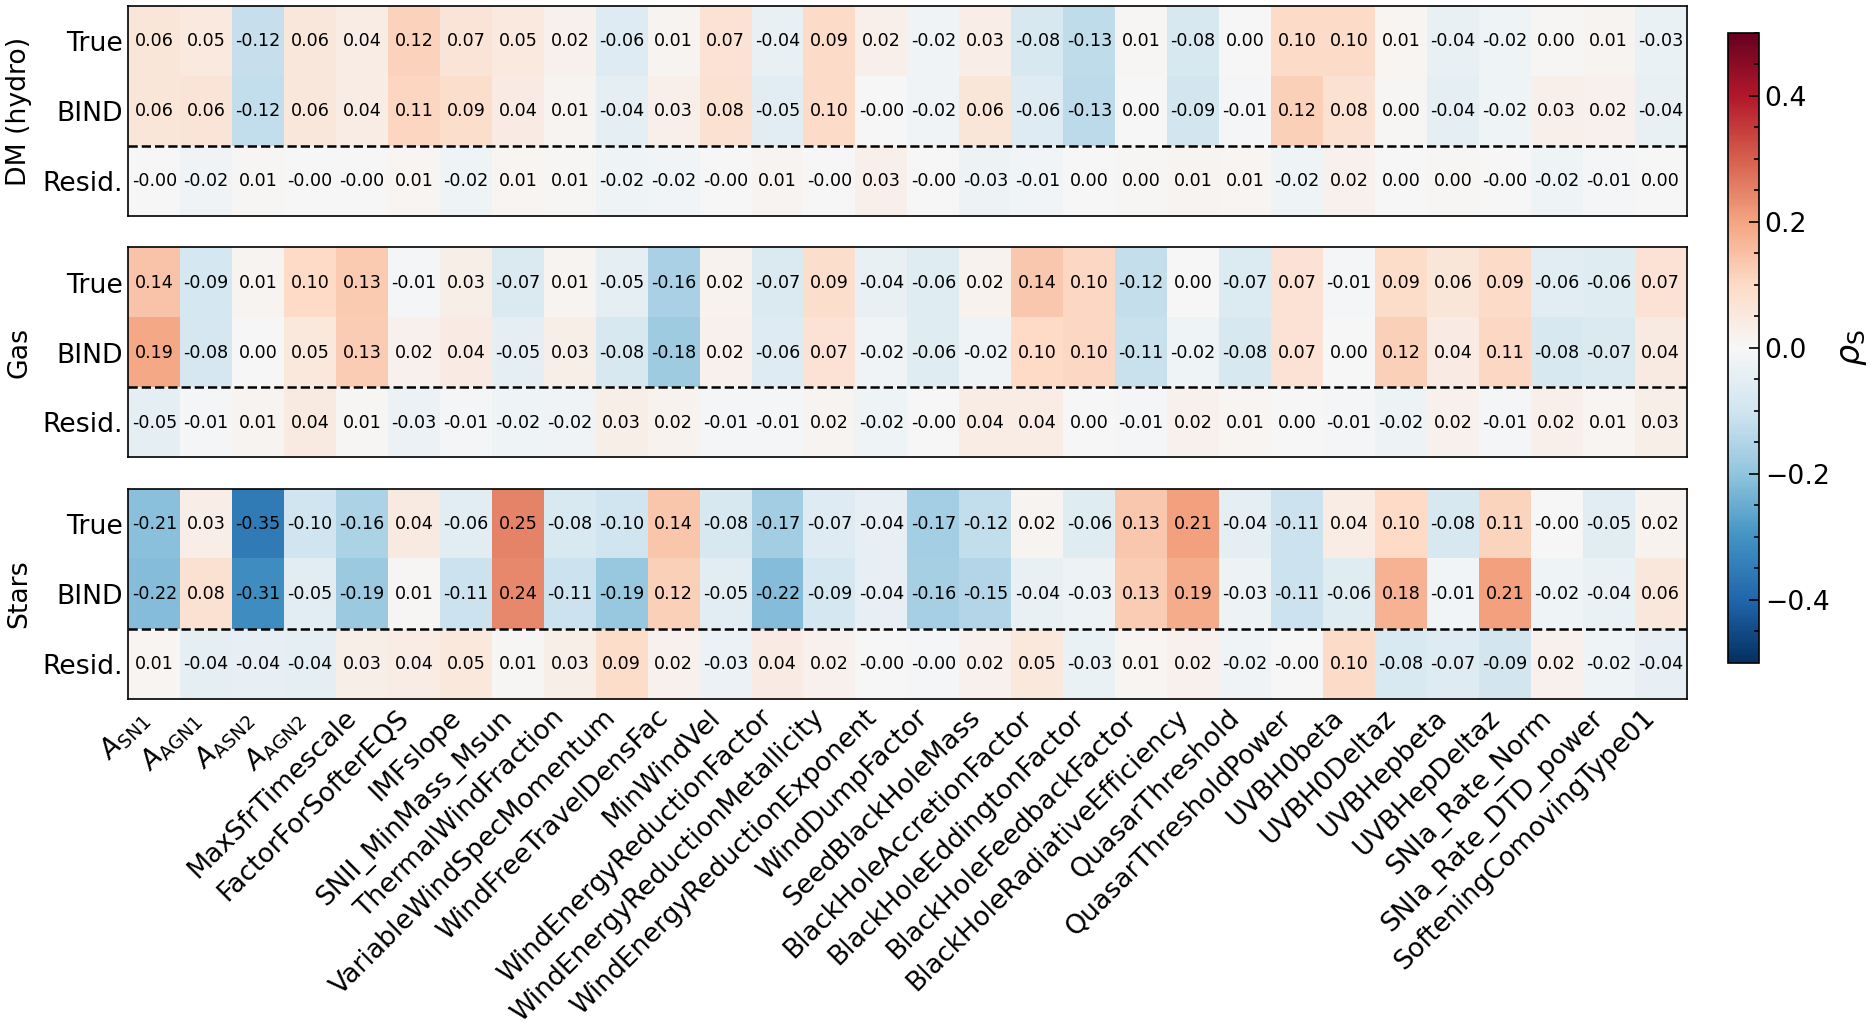

In [11]:
from scipy.stats import spearmanr

param_cols = [f'p{j+1}' for j in range(N_PARAMS)]
param_labels_all = [PARAM_LABELS[j+1] for j in range(N_PARAMS)]

CH_DISPLAY = {'DM_hydro': 'DM (hydro)', 'Gas': 'Gas', 'Stars': 'Stars'}

sources = [('True', 'true_logmean_{}'), ('BIND', 'gen_logmean_{}')]

rho_all  = {src: np.full((len(CHANNEL_NAMES), N_PARAMS), np.nan) for src, _ in sources}
pval_all = {src: np.full((len(CHANNEL_NAMES), N_PARAMS), np.nan) for src, _ in sources}

for src, col_tpl in sources:
    for ci, ch in enumerate(CHANNEL_NAMES):
        y = sim_tbl[col_tpl.format(ch)].to_numpy()
        for j, pcol in enumerate(param_cols):
            x = sim_tbl[pcol].to_numpy()
            mask = np.isfinite(x) & np.isfinite(y)
            if mask.sum() < 5:
                continue
            r, p = spearmanr(x[mask], y[mask])
            rho_all[src][ci, j]  = r
            pval_all[src][ci, j] = p

TOP_P      = 35
_excluded  = {0, 1, 6, 7, 8}
max_rho    = np.nanmax(np.abs(rho_all['True']), axis=0)
param_order = np.argsort(max_rho)[::-1]
top_idx     = [pi for pi in param_order if pi not in _excluded][:TOP_P]
top_idx_sorted = sorted(top_idx)

xlabels = [param_labels_all[i] for i in top_idx_sorted]

vmax = 0.5
fig, axes = plt.subplots(len(CHANNEL_NAMES), 1,
                         figsize=(17.2, 7.5),
                         sharex=True,
                         gridspec_kw={'hspace': 0.15})

ims = []
for ci, (ch, ax) in enumerate(zip(CHANNEL_NAMES, axes)):
    rho_true = rho_all['True'][ci, top_idx_sorted]
    rho_bind = rho_all['BIND'][ci, top_idx_sorted]
    rho_resid = rho_true - rho_bind   # residual in same ρ_S units

    data = np.vstack([rho_true, rho_bind, rho_resid])
    pdat = np.vstack([pval_all['True'][ci, top_idx_sorted],
                      pval_all['BIND'][ci, top_idx_sorted],
                      np.full(len(top_idx_sorted), np.nan)])  # no p-val for residual

    im = ax.imshow(data, aspect='auto', cmap='RdBu_r',
                   vmin=-vmax, vmax=vmax)
    ims.append(im)

    for ri, src_label in enumerate(['True', 'BIND', 'Residual']):
        for xj in range(len(top_idx_sorted)):
            if src_label == 'Residual' and np.isnan(rho_resid[xj]):
                continue
            r = data[ri, xj]
            if np.isnan(r):
                continue
            txt_color = 'white' if abs(r) > 0.45 else 'black'
            ax.text(xj, ri, f'{r:.2f}', ha='center', va='center',
                        fontsize=10.5, color=txt_color)

    # divider line between BIND and Residual rows
    ax.axhline(1.5, color='k', lw=1.5, ls='--')

    ax.set_yticks([0, 1, 2])
    ax.set_yticklabels(['True', 'BIND', 'Resid.'])
    ax.set_ylabel(CH_DISPLAY[ch], labelpad=6)
    ax.tick_params(left=False)
    ax.tick_params(axis='both', which='both', length=0)

axes[-1].set_xticks(range(len(top_idx_sorted)))
axes[-1].set_xticklabels(xlabels, rotation=45, ha='right')

fig.subplots_adjust(right=0.88)
cax = fig.add_axes([0.90, 0.15, 0.015, 0.7])
cbar = fig.colorbar(ims[0], cax=cax)
cbar.set_label(r"$\rho_{\rm S}$", fontsize=20)

save_fig(fig, 'fig3_spearman_param_mass')
plt.show()

## Radial Profiles (Fig 4)

Stack halo profiles across mass bins. *~1–2 min*

In [13]:
def stack_radial_profiles(sims_df, mass_edges, n_bins=32):
    """Compute per-halo radial profiles; return arrays grouped by mass bin.

    Returns dict[mass_bin_idx] -> {
        'r': (n_bins,) physical radius [Mpc/h],
        'truth': (N, 3, n_bins),  'gen': (N, 3, n_bins),
        'n_halos': int,
    }
    """
    mpc_per_pix = PATCH_BOX / PATCH_PIX
    r_pix = None
    bins = [[] for _ in range(len(mass_edges) - 1)]  # (truth, gen) lists per bin

    for rec in sims_df.to_dict('records'):
        try:
            truth, gen, masses, *_ = halo_patches(rec)
        except Exception:
            continue
        logm = np.log10(masses)
        for h in range(len(masses)):
            bi = np.searchsorted(mass_edges, logm[h], side='right') - 1
            if bi < 0 or bi >= len(mass_edges) - 1:
                continue
            t_profs, g_profs = [], []
            for c in range(3):
                r_p, t_prof = radial_profile(truth[h, c], n_bins=n_bins, logspace=False)
                _,   g_prof = radial_profile(gen[h, c],   n_bins=n_bins, logspace=False)
                t_profs.append(t_prof); g_profs.append(g_prof)
                if r_pix is None:
                    r_pix = r_p
            bins[bi].append((np.stack(t_profs), np.stack(g_profs)))

    out = {}
    for bi, samples in enumerate(bins):
        if not samples:
            continue
        t_all = np.stack([s[0] for s in samples])  # (N, 3, n_bins)
        g_all = np.stack([s[1] for s in samples])
        out[bi] = {
            'r': r_pix * mpc_per_pix,
            'truth': t_all,
            'gen': g_all,
            'n_halos': len(samples),
        }
    return out


MASS_EDGES = [13.0, 13.3, 13.7, 15.5]
print('Stacking CV radial profiles across mass bins...')
prof_cv = stack_radial_profiles(cv_sims, MASS_EDGES)
for bi, d in prof_cv.items():
    print(f'  bin {bi}  (logM in [{MASS_EDGES[bi]:.1f}, {MASS_EDGES[bi+1]:.1f}]):'
          f' {d["n_halos"]} halos')
    
print('Stacking 1P radial profiles...')
prof_1p = stack_radial_profiles(oneP_sims, MASS_EDGES)
for bi, d in prof_1p.items():
    print(f'  bin {bi}  (logM in [{MASS_EDGES[bi]:.1f}, {MASS_EDGES[bi+1]:.1f}]):'
          f' {d["n_halos"]} halos')

print('Stacking Test radial profiles...')
prof_test = stack_radial_profiles(test_sims, MASS_EDGES)
for bi, d in prof_test.items():
    print(f'  bin {bi}  (logM in [{MASS_EDGES[bi]:.1f}, {MASS_EDGES[bi+1]:.1f}]):'
          f' {d["n_halos"]} halos')


Stacking CV radial profiles across mass bins...
  bin 0  (logM in [13.0, 13.3]): 643 halos
  bin 1  (logM in [13.3, 13.7]): 355 halos
  bin 2  (logM in [13.7, 15.5]): 156 halos
Stacking 1P radial profiles...
  bin 0  (logM in [13.0, 13.3]): 4123 halos
  bin 1  (logM in [13.3, 13.7]): 1616 halos
  bin 2  (logM in [13.7, 15.5]): 1084 halos
Stacking Test radial profiles...
  bin 0  (logM in [13.0, 13.3]): 2230 halos
  bin 1  (logM in [13.3, 13.7]): 1403 halos
  bin 2  (logM in [13.7, 15.5]): 639 halos


  wrote paper_figures/fig_radial_pct_diff.pdf
  wrote paper_figures/fig_radial_pct_diff.png


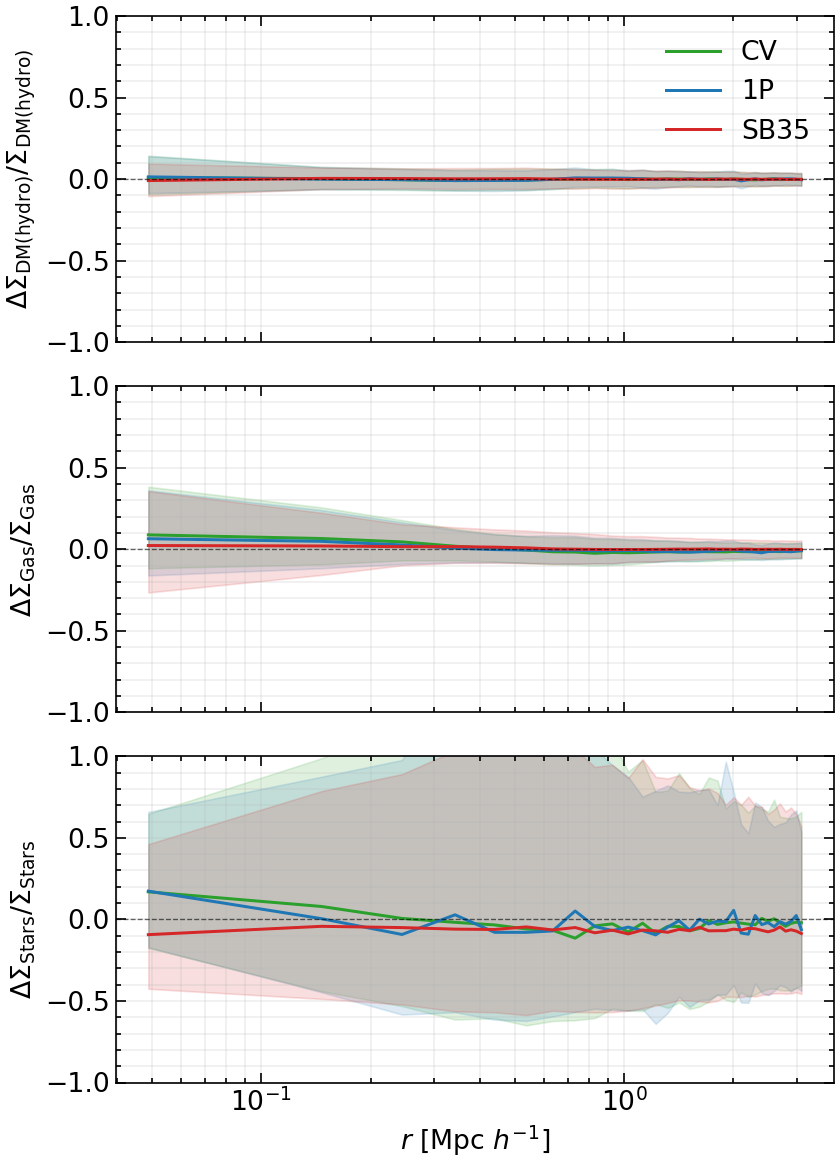

In [14]:

def _pool_prof(prof_dict):
    """Pool all halos across mass bins; return r (n_r,) and pct_diff stats (3, n_r).

    Returns median, 16th, and 84th percentile of 100*(gen - truth)/truth.
    """
    t_ch = [[] for _ in range(3)]
    g_ch = [[] for _ in range(3)]
    r = None
    for d in prof_dict.values():
        if r is None:
            r = d['r']
        for c in range(3):
            t_ch[c].append(d['truth'][:, c, :])  # (N, n_r)
            g_ch[c].append(d['gen'][:, c, :])

    med = np.zeros((3, len(r)))
    p16 = np.zeros((3, len(r)))
    p84 = np.zeros((3, len(r)))
    for c in range(3):
        t = np.concatenate(t_ch[c], axis=0)
        g = np.concatenate(g_ch[c], axis=0)
        with np.errstate(divide='ignore', invalid='ignore'):
            ph = np.where(t > 0, (g - t) / t, np.nan)
        med[c] = np.nanmedian(ph, axis=0)
        p16[c] = np.nanpercentile(ph, 16, axis=0)
        p84[c] = np.nanpercentile(ph, 84, axis=0)
    return r, med, p16, p84

def fig4_radial_pct_diff(save=True):
    suite_profs = {'CV': prof_cv, '1P': prof_1p, 'Test': prof_test}
    ch_names = {0: 'DM (hydro)', 1: 'Gas', 2: 'Stars'}
    fig, axes = plt.subplots(3, 1, figsize=(7.2, 3.3*3), sharey=True, sharex=True)
    for c, (ax, ch) in enumerate(zip(axes, ch_names.values())):
        for suite, pd in suite_profs.items():
            r, med, p16, p84 = _pool_prof(pd)
            n = sum(d['n_halos'] for d in pd.values())
            color = SUITE_COLORS[suite]
            ax.fill_between(r, p16[c], p84[c], color=color, alpha=0.15)
            if c == 0:
                ax.plot(r, med[c], color=color, lw=1.8,
                    label=f'{SUITE_DISPLAY[suite]}')
            else:
                ax.plot(r, med[c], color=color, lw=1.8)
        ax.axhline(0.0, color='k', lw=0.8, ls='--', alpha=0.6)
        ax.set_xscale('log')
        ax.set_ylim(-1, 1)
        # ax.set_title(ch)
        ax.grid(which='both', alpha=0.2)
        ax.set_ylabel(rf'$\Delta \Sigma_{{\rm {ch}}} / \Sigma_{{\rm {ch}}}$')
        if c == 0:
            ax.legend(loc='best')
        if c==2:
            ax.set_xlabel(r'$r$ [Mpc $h^{-1}$]')


    fig.tight_layout()
    if save:
        save_fig(fig, 'fig_radial_pct_diff')
    return fig


fig = fig4_radial_pct_diff()
plt.show()


## Spearman Correlation: Parameters vs Radial Profile (Fig 3b)

Build per-sim mean profiles in r/R₂₀₀, then plot Spearman heatmap. *~100 s*

In [15]:
# ── Per-sim mean radial profiles in r/R₂₀₀ units ─────────────────────────────
N_PROF_BINS  = 16
MPC_PER_PIX  = PATCH_BOX / PATCH_PIX

# Normalized radial grid: 0 → 2 R₂₀₀ (exclusive of 0 to avoid log issues)
R_OVER_R200  = np.linspace(0.05, 2.0, N_PROF_BINS)   # shape (N_PROF_BINS,)

def collect_sim_profiles_r200(sims_df, n_bins=N_PROF_BINS):
    """Per-sim mean radial profiles in r/R₂₀₀ for True and BIND."""
    rows = []
    for rec in sims_df.to_dict('records'):
        try:
            truth_p, gen_p, masses, *_ = halo_patches(rec)
            cat = load_catalog(rec)
        except Exception as exc:
            print(f'[skip] {rec["suite"]}/{rec["sim_id"]}: {exc}')
            continue
        if 'params' not in cat or len(cat['params']) == 0:
            continue
        params = np.asarray(cat['params'][0], np.float64)
        n_halos = len(masses)

        t_profs = np.zeros((n_halos, 3, n_bins))
        g_profs = np.zeros((n_halos, 3, n_bins))

        for h in range(n_halos):
            r200_pix = _r200c_pix(masses[h])   # scalar, in patch pixels

            # compute a fine pixel-space profile then interpolate
            r_pix_fine, _ = radial_profile(truth_p[h, 0], n_bins=64, logspace=False)
            r_interp_pix  = R_OVER_R200 * r200_pix   # target radii in pixels

            for c in range(3):
                _, tp_fine = radial_profile(truth_p[h, c], n_bins=64, logspace=False)
                _, gp_fine = radial_profile(gen_p[h, c],   n_bins=64, logspace=False)
                # clip interpolation to the range of the fine grid
                r_query = np.clip(r_interp_pix, r_pix_fine[0], r_pix_fine[-1])
                t_profs[h, c] = np.interp(r_query, r_pix_fine, tp_fine)
                g_profs[h, c] = np.interp(r_query, r_pix_fine, gp_fine)

        t_mean = np.nanmean(t_profs, axis=0)   # (3, n_bins)
        g_mean = np.nanmean(g_profs, axis=0)

        row = {'suite': rec['suite'], 'sim_id': rec['sim_id']}
        for j in range(N_PARAMS):
            row[f'p{j+1}'] = params[j]
        for c, ch in enumerate(CHANNEL_NAMES):
            for k in range(n_bins):
                row[f'true_prof_{ch}_{k}'] = float(t_mean[c, k])
                row[f'gen_prof_{ch}_{k}']  = float(g_mean[c, k])
        rows.append(row)

    return pd.DataFrame(rows)


print('Computing per-sim mean radial profiles in r/R₂₀₀ (~100 s)...')
prof_tbl  = collect_sim_profiles_r200(sims)
r_bins_mpc = R_OVER_R200   # now these are r/R₂₀₀ values, not Mpc/h
print(f'Profile rows: {len(prof_tbl)}')
print(prof_tbl.groupby('suite').size())
print(f'r/R₂₀₀ bins: {np.round(r_bins_mpc, 2)}')

Computing per-sim mean radial profiles in r/R₂₀₀ (~100 s)...


KeyboardInterrupt: 

In [ ]:
# Log-spaced display grid (same number of rows, log-spaced in r/R₂₀₀)
R_LOG = np.logspace(np.log10(R_OVER_R200[0]), np.log10(R_OVER_R200[-1]), N_PROF_BINS)
r1_row = np.argmin(np.abs(R_LOG - 1.0))   # row index of r/R₂₀₀ = 1

def _resample_to_log(mat):
    """Resample rows of mat from linear R_OVER_R200 → log R_LOG."""
    out = np.full_like(mat, np.nan)
    for j in range(mat.shape[1]):
        col = mat[:, j]
        valid = np.isfinite(col)
        if valid.sum() < 2:
            continue
        out[:, j] = np.interp(R_LOG, R_OVER_R200[valid], col[valid])
    return out

rho_sub_true  = [m[:, top_idx_sorted] for m in rho_prof['True']]
rho_sub_bind  = [m[:, top_idx_sorted] for m in rho_prof['BIND']]
rho_sub_resid = [t - b for t, b in zip(rho_sub_true, rho_sub_bind)]

vmax_p = 0.5
fig, axes = plt.subplots(len(CHANNEL_NAMES), 2,
                         figsize=(15, 10),
                         sharex=True, sharey=True,
                         gridspec_kw={'hspace': 0.15, 'wspace': 0.04})

# Ticks at nice log-spaced r/R₂₀₀ values
r_tick_vals = [0.1, 0.2, 0.5, 1.0, 2.0]
r_tick_idx  = [np.argmin(np.abs(R_LOG - v)) for v in r_tick_vals]
r_tick_lbls = [str(v) for v in r_tick_vals]

ims = []
for ci, ch in enumerate(CHANNEL_NAMES):
    for si, (src_label, data) in enumerate([('BIND',        rho_sub_bind[ci]),
                                             ('True − BIND', rho_sub_resid[ci])]):
        ax = axes[ci, si]
        im = ax.imshow(_resample_to_log(data), aspect='auto', cmap='RdBu_r',
                       vmin=-vmax_p, vmax=vmax_p, origin='upper',
                       interpolation='nearest')
        ims.append(im)

        # horizontal line at r/R₂₀₀ = 1
        ax.axhline(r1_row, color='k', lw=1.2, ls='--', alpha=0.7)

        if si == 0:
            ax.set_ylabel(f'$\Sigma_{{{CH_DISPLAY[ch]}}}$\n$r/R_{{200}}$')
        if ci == 0:
            ax.set_title(src_label, pad=4)
        if si == 0:
            ax.spines['right'].set_visible(True)
            ax.spines['right'].set_linewidth(1.5)

for ci in range(len(CHANNEL_NAMES)):
    axes[ci, 0].set_yticks(r_tick_idx)
    axes[ci, 0].set_yticklabels(r_tick_lbls, fontsize=10)
    axes[ci, 0].tick_params(axis='both', which='both', length=0)
    axes[ci, 1].tick_params(axis='both', which='both', labelleft=False, length=0)

axes[-1, 0].set_xticks(range(len(top_idx_sorted)))
axes[-1, 0].set_xticklabels(xlabels, rotation=45, ha='right', fontsize=10)
axes[-1, 1].set_xticks(range(len(top_idx_sorted)))
axes[-1, 1].set_xticklabels(xlabels, rotation=45, ha='right', fontsize=10)

fig.subplots_adjust(right=0.88)
cax = fig.add_axes([0.90, 0.15, 0.015, 0.7])
cbar = fig.colorbar(ims[0], cax=cax)
cbar.set_label(r"$\rho_{S}$")

save_fig(fig, 'fig3_spearman_profile')
plt.show()


## Full-Box Power Spectra (Fig 5)

In [ ]:
def _pct_band(arr):
    return np.median(arr, 0), np.quantile(arr, 0.16, 0), np.quantile(arr, 0.84, 0)


def _collect_pk_fresh(sims_df, box_size=BOX_SIZE, threads=4):
    """Recompute DMO/truth/bind/hydro-replace total-field P(k) straight from
    disk so we never plot a stale cv_pk_replace_t. Skips are reported loudly."""
    k_ref = None
    pd_, pt_, pb_, pr_ = [], [], [], []
    n_skip = 0
    for rec in sims_df.to_dict('records'):
        try:
            fm = load_full_maps(rec)
            comp = load_composite(rec)
            replace = np.load(Path(rec['composite']).parent / 'hydro_replace.npy')
        except Exception as exc:
            n_skip += 1
            continue
        dmo = fm['dmo_fullbox']
        k, pk, _ = power_spectrum_pylians_2d(dmo, box_size=box_size, MAS='None', threads=threads)
        if k_ref is None:
            k_ref = k
        pd_.append(pk)
        _, pt, _ = power_spectrum_pylians_2d(fm['truth_maps'].sum(0), box_size=box_size, MAS='None', threads=threads)
        pt_.append(pt)
        _, pb, _ = power_spectrum_pylians_2d(comp['composite'].sum(0), box_size=box_size, MAS='None', threads=threads)
        pb_.append(pb)
        _, pr, _ = power_spectrum_pylians_2d(replace.sum(0), box_size=box_size, MAS='None', threads=threads)
        pr_.append(pr)
    if n_skip:
        print(f'  [warn] skipped {n_skip} sims (missing hydro_replace.npy)')
    return k_ref, np.stack(pd_), np.stack(pt_), np.stack(pb_), np.stack(pr_)

In [ ]:
k_cv, cd, ct, cb, cr = _collect_pk_fresh(cv_sims)
k_sb, td, tt, tb, tr = _collect_pk_fresh(test_sims)

In [ ]:
def fig5b_total_field_pk(k_cv, cd, ct, cb, cr, k_sb, td, tt, tb, tr, save=True):

    suites = [('CV', k_cv, cd, ct, cb, cr), ('SB35', k_sb, td, tt, tb, tr)]

    k_nyquist = np.pi * 1024 / 50.0   # Nyquist: 50 Mpc/h box, 1024^2 pixels

    fig, axes = plt.subplots(2, 2, figsize=(11, 9),
                             gridspec_kw={'height_ratios': [2, 1], 'hspace': 0.0, 'wspace': 0.25}, sharex=True, sharey=True)

    for col, (name, k, pk_dmo, pk_truth, pk_bind, pk_hr) in enumerate(suites):
        ax_top = axes[0, col]
        ax_bot = axes[1, col]

        dmo_med = np.median(pk_dmo, axis=0)
        dmo_ref = np.where(dmo_med > 0, dmo_med, np.nan)

        with np.errstate(divide='ignore', invalid='ignore'):
            s_truth = pk_truth / dmo_ref
            s_bind  = pk_bind  / dmo_ref
            s_hr    = pk_hr    / dmo_ref
            t_ref   = np.where(pk_truth > 0, pk_truth, np.nan)
            r_bind  = pk_bind / t_ref
            r_dmo   = pk_dmo  / np.where(np.median(pk_truth, axis=0) > 0,
                                         np.median(pk_truth, axis=0), np.nan)
            r_hr    = pk_hr   / t_ref

        st_med = _pct_band(s_truth)[0]
        sb_med, sb_lo, sb_hi = _pct_band(s_bind)
        sh_med, sh_lo, sh_hi = _pct_band(s_hr)
        rb_med, rb_lo, rb_hi = _pct_band(r_bind)
        rd_med = _pct_band(r_dmo)[0]
        rh_med = _pct_band(r_hr)[0]

        mask = np.isfinite(st_med) & np.isfinite(sb_med) & (st_med > 0) & (sb_med > 0)
        kk = k[mask]
        def _m(a): return a[mask]

        # Top panel
        ax_top.plot(kk, _m(st_med), color='k', lw=1.4, label='Truth / DMO')

        # BIND/DMO: fill_between + median line
        # ax_top.fill_between(kk, _m(sb_lo), _m(sb_hi), color='tab:orange', alpha=0.25, lw=0)
        ax_top.plot(kk, _m(sb_med), color='tab:orange', lw=1.4, label='BIND / DMO')

        # Hydro-replaced/DMO: points with errorbars (subsample every 4 for readability)
        sl = slice(None, None, 4)
        ax_top.plot(kk[sl], _m(sh_med)[sl],
                        color='tab:blue', 
                        label='Hydro-replaced / DMO')

        ax_top.axhline(1.0, color='gray', lw=0.6, ls='--', alpha=0.6)
        ax_top.set_xscale('log')
        ax_top.set_xlim(right=k_nyquist)
        ax_top.tick_params(labelbottom=False)
        # ax_top.set_title(f'{name}  (n={pk_truth.shape[0]})')
        ax_top.grid(which='both', alpha=0.25)
        if col == 0:
            ax_top.set_ylabel(r'$P(k) / P_{\rm DMO}(k)$')
            ax_top.legend(loc='best')

        # Bottom panel
        ax_bot.axhspan(0.8, 1.2, color='tab:green', alpha=0.08, lw=0)
        ax_bot.axhline(1.0, color='k', lw=0.6, ls='--')

        # BIND/Truth: fill_between + median line
        ax_bot.fill_between(kk, _m(rb_lo), _m(rb_hi), color='tab:orange', alpha=0.25, lw=0)
        ax_bot.plot(kk, _m(rb_med), color='tab:orange', lw=1.3, label='BIND / Truth')

        ax_bot.plot(kk, _m(rd_med), color='tab:gray',   lw=1.0, ls='--', label='DMO / Truth')
        ax_bot.plot(kk, _m(rh_med), color='tab:blue',   lw=1.0, ls='-.', label='Hydro-replaced / Truth')
        ax_bot.set_xscale('log')
        ax_bot.set_xlim(right=k_nyquist)
        ax_bot.set_ylim(0.5, 1.5)
        ax_bot.grid(which='both', alpha=0.25)
        ax_bot.set_xlabel(r'$k$ [$h/\mathrm{Mpc}$]')
        if col == 0:
            ax_bot.set_ylabel(r'$P / P_{\rm Truth}$')
            ax_bot.legend(loc='lower left')


    fig.tight_layout(rect=(0, 0.01, 1, 0.985))
    if save:
        save_fig(fig, 'fig5b_total_field_pk')
    return fig

fig = fig5b_total_field_pk(k_cv, cd, ct, cb, cr, k_sb, td, tt, tb, tr)
plt.show()

## 1P Field Response (Fig 6)

In [ ]:
def find_1p_pair(param_idx, variant_hi='2', variant_lo='n2'):
    sid_hi = f'1P_p{param_idx}_{variant_hi}'
    sid_lo = f'1P_p{param_idx}_{variant_lo}'
    hi = oneP_sims[oneP_sims['sim_id'] == sid_hi]
    lo = oneP_sims[oneP_sims['sim_id'] == sid_lo]
    if len(hi) == 0 or len(lo) == 0:
        return None, None
    return hi.iloc[0].to_dict(), lo.iloc[0].to_dict()


def most_massive_patches(rec):
    truth, gen, masses, *_ = halo_patches(rec)
    i = int(np.argmax(masses))
    return truth[i], gen[i], float(masses[i])


oneP_valid_params = []
for j in range(1, N_PARAMS + 1):
    hi, lo = find_1p_pair(j)
    if hi is not None:
        oneP_valid_params.append(j)
print(f'Valid 1P pairs (variant 2 & n2 both present): {len(oneP_valid_params)}')
print(' params:', oneP_valid_params)


In [ ]:
COSMO_PARAM_IDX = {1, 2, 7, 8, 9}   # Omega_m, sigma8, OmegaBaryon, HubbleParam, n_s


def _compute_1p_log_ratios(param_indices):
    """Build (log_ratios, ch_floors, fields) for the most-massive halo of each
    valid 1P pair. log_ratios[j] = dict(t=(C,H,W), g=(C,H,W)) in dex.

    Per-channel adaptive floor = 1e-3 * 99th-pct of all non-zero pixels across
    both variants & all params, so zero-zero pixels stay at log ratio = 0.
    """
    n_ch = len(CHANNEL_NAMES)
    fields = {}
    for j in param_indices:
        hi, lo = find_1p_pair(j)
        if hi is None:
            continue
        t_hi, g_hi, _ = most_massive_patches(hi)
        t_lo, g_lo, _ = most_massive_patches(lo)
        fields[j] = dict(t_hi=t_hi, t_lo=t_lo, g_hi=g_hi, g_lo=g_lo)

    ch_floors = []
    for c in range(n_ch):
        nonzero_parts = []
        for fd in fields.values():
            for key in ('t_hi', 't_lo', 'g_hi', 'g_lo'):
                v = fd[key][c].ravel()
                nonzero_parts.append(v[v > 0])
        if nonzero_parts:
            nonzero_all = np.concatenate(nonzero_parts)
            floor = float(np.percentile(nonzero_all, 99)) * 1e-3
        else:
            floor = 1e-8
        ch_floors.append(max(floor, 1e-12))

    log_ratios = {}
    eps = np.array(ch_floors).reshape(n_ch, 1, 1)
    for j, fd in fields.items():
        t_lr = np.log10((fd['t_hi'] + eps) / (fd['t_lo'] + eps))
        g_lr = np.log10((fd['g_hi'] + eps) / (fd['g_lo'] + eps))
        log_ratios[j] = dict(t=t_lr, g=g_lr)
    return log_ratios, ch_floors, fields


def _logratio_panel_metrics(t_lr, g_lr):
    """Pearson r between truth & BIND2 log-ratio fields, and amplitude ratio
    std(BIND2) / std(truth). NaN r when either side has no spatial variation.
    """
    from scipy.stats import pearsonr
    t = t_lr.ravel().astype(np.float64)
    g = g_lr.ravel().astype(np.float64)
    s_t, s_g = float(np.std(t)), float(np.std(g))
    A = (s_g / s_t) if s_t > 0 else np.nan
    if s_t < 1e-12 or s_g < 1e-12:
        return np.nan, A
    return float(pearsonr(t, g).statistic), A


def fig7_1p_field_response(param_indices, save=True):
    from matplotlib.colors import Normalize
    from matplotlib.cm import ScalarMappable
    import matplotlib.gridspec as gridspec

    n_ch = len(CHANNEL_NAMES)
    n_rows = len(param_indices)
    n_col_per_ch = 2
    n_cols = n_ch * n_col_per_ch

    log_ratios, ch_floors, _ = _compute_1p_log_ratios(param_indices)

    # per-channel symmetric vmax = 99.5th pct of |log ratio|
    norms, ch_vmax = [], []
    for c in range(n_ch):
        all_abs = np.concatenate([
            np.abs(log_ratios[j]['t'][c]).ravel() for j in log_ratios
        ] + [
            np.abs(log_ratios[j]['g'][c]).ravel() for j in log_ratios
        ])
        v = float(np.quantile(all_abs, 0.995)) if len(all_abs) else 1.0
        if v == 0 or np.isnan(v):
            v = 0.1
        ch_vmax.append(v)
        norms.append(Normalize(vmin=-v, vmax=v))

    def _short(ch):
        return ch.replace('DM_hydro', 'DM').replace('_', ' ')

    cell = 2.0
    fig = plt.figure(figsize=(cell * n_cols + 1.2, cell * n_rows + 0.9))
    gs = gridspec.GridSpec(
        n_rows + 1, n_cols,
        figure=fig,
        height_ratios=[1.0] * n_rows + [0.08],
        hspace=0.05, wspace=0.05,
        left=0.12, right=0.99, top=0.95, bottom=0.08,
    )
    axes = [[fig.add_subplot(gs[r, c]) for c in range(n_cols)] for r in range(n_rows)]
    cbar_axes = [
        fig.add_subplot(gs[n_rows, c * n_col_per_ch:(c + 1) * n_col_per_ch])
        for c in range(n_ch)
    ]

    metric_rows = []
    for ri, j in enumerate(param_indices):
        label = PARAM_LABELS.get(j, f'p{j}')
        if j not in log_ratios:
            for ci in range(n_cols):
                axes[ri][ci].axis('off')
            continue
        lr = log_ratios[j]
        for c in range(n_ch):
            r, A = _logratio_panel_metrics(lr['t'][c], lr['g'][c])
            metric_rows.append({'param_idx': j, 'channel': CHANNEL_NAMES[c],
                                'pearson_r': r, 'amp_ratio': A})
            for ki, (field, kind) in enumerate(
                [(lr['t'][c], 'Truth'), (lr['g'][c], 'BIND')]
            ):
                col = c * n_col_per_ch + ki
                ax = axes[ri][col]
                ax.imshow(field, origin='lower', cmap='RdBu_r', norm=norms[c])
                ax.set_xticks([]); ax.set_yticks([])
                if ri == 0:
                    ax.set_title(f'{_short(CHANNEL_NAMES[c])}\n{kind}', fontsize=9)
                if col == 0:
                    ax.set_ylabel(label, fontsize=11, rotation=0,
                                  labelpad=42, ha='right', va='center')
                if kind == 'BIND2':
                    if np.isfinite(r):
                        txt = f'$r{{=}}${r:+.2f}\n$A{{=}}${A:.2f}'
                    else:
                        txt = f'$A{{=}}${A:.2f}'
                    ax.text(0.04, 0.96, txt, transform=ax.transAxes,
                            fontsize=7, va='top', ha='left', color='black',
                            bbox=dict(facecolor='white', edgecolor='none',
                                      alpha=0.75, pad=1.2))

    for c, cax in enumerate(cbar_axes):
        sm = ScalarMappable(norm=norms[c], cmap='RdBu_r')
        sm.set_array([])
        cb = fig.colorbar(sm, cax=cax, orientation='horizontal')
        cb.set_label(fr'{_short(CHANNEL_NAMES[c])}  $\log_{{10}}$(hi/lo)  [dex]', fontsize=8)
        cb.ax.tick_params(labelsize=7)

    if save:
        save_fig(fig, 'fig7_1p_field_response')
    fig._logratio_metrics = pd.DataFrame(metric_rows)
    return fig


# Astrophysical parameters only (exclude Omega_m, sigma_8, Omega_b, h, n_s)
HERO_PARAMS = [p for p in oneP_valid_params if p not in COSMO_PARAM_IDX]
print(f'Astrophysical valid 1P params: {HERO_PARAMS}')
# [3, 4, 5, 12, 13, 25]
fig = fig7_1p_field_response([3, 4, 5, 12, 13, 25])
plt.show()


## Halo Shape Analysis (Fig 7)

Compute mass-weighted 2D quadrupole moments; plot axis-ratio distributions. *~1–2 min*

In [ ]:
# ─── Shape-analysis helpers ────────────────────────────────────────────────
_PIX_MPC     = PATCH_BOX / PATCH_PIX          # 6.25/128 Mpc/h per pixel
_STAR_THRESH = 1e-3                            # min stellar density for lit pixels


def compute_r200_pix(halo_masses_msun_h, pix_size_mpc_h=_PIX_MPC, omega_m=0.3089):
    """r200 in pixels from halo mass in M_sun/h.

    In h-free comoving units:  rho_m = 2.775e11 * Omega_m  [(M_sun/h)/(Mpc/h)^3].
    """
    rho_m = 2.775e11 * omega_m
    r200  = (3 * np.asarray(halo_masses_msun_h) / (4 * np.pi * 200 * rho_m)) ** (1.0 / 3.0)
    return r200 / pix_size_mpc_h


def compute_shape_moments_batch(maps, threshold=0.0, aperture_radii=None, min_pixels=5):
    """Mass-weighted 2D quadrupole moments for a batch of maps.

    Parameters
    ----------
    maps           : (N, H, W) float array
    threshold      : zero-clip level before weighting
    aperture_radii : scalar or (N,) array of pixel radii, or None (full map)
    min_pixels     : minimum weighted pixels for a valid measurement

    Returns
    -------
    q, e1, e2 : (N,) arrays — axis ratio and ellipticity components (NaN if invalid)
    """
    N, H, W = maps.shape
    yy, xx  = np.mgrid[0:H, 0:W].astype(np.float64)
    cx, cy  = (W - 1) / 2.0, (H - 1) / 2.0
    dist2   = (xx - cx) ** 2 + (yy - cy) ** 2
    per_halo = (aperture_radii is not None) and not np.isscalar(aperture_radii)

    q_out  = np.full(N, np.nan)
    e1_out = np.full(N, np.nan)
    e2_out = np.full(N, np.nan)

    for i in range(N):
        if aperture_radii is None:
            aperture = np.ones((H, W), dtype=np.float64)
        else:
            r = float(aperture_radii[i]) if per_halo else float(aperture_radii)
            aperture = (dist2 <= r ** 2).astype(np.float64)

        w = np.maximum(maps[i].astype(np.float64) - threshold, 0.0) * aperture
        total = w.sum()
        if total < 1e-30 or int((w > 0).sum()) < min_pixels:
            continue

        x_c = (xx * w).sum() / total
        y_c = (yy * w).sum() / total
        dx, dy = xx - x_c, yy - y_c
        Qxx = (dx ** 2 * w).sum() / total
        Qyy = (dy ** 2 * w).sum() / total
        Qxy = (dx * dy * w).sum() / total

        evals, evecs = np.linalg.eigh([[Qxx, Qxy], [Qxy, Qyy]])
        lam_min, lam_max = evals[0], evals[1]
        if lam_max < 1e-30 or lam_min < 0:
            continue

        q   = np.sqrt(lam_min / lam_max)
        pa  = np.arctan2(evecs[1, 1], evecs[0, 1])
        eps = (1 - q) / (1 + q)
        q_out[i]  = q
        e1_out[i] = eps * np.cos(2 * pa)
        e2_out[i] = eps * np.sin(2 * pa)

    return q_out, e1_out, e2_out


def _shape_eps(e1, e2):
    return np.hypot(e1, e2)


def _shape_pa(e1, e2):
    return 0.5 * np.arctan2(e2, e1)


def _angle_diff_deg(pa1, pa2):
    diff = np.degrees(pa1 - pa2)
    diff = ((diff + 90) % 180) - 90
    return np.abs(diff)


In [ ]:
def collect_shape_table(sims_df):
    """Compute mass-weighted 2D shape moments for all halos across a sim suite.

    Loads truth / generated 128-pixel patches and DMO condition patches from
    the full-box maps, applies per-halo r200 apertures, and returns a dict of
    shape-metric arrays.

    Returns
    -------
    dict with N-length arrays (N = total halos):
      suite, halo_mass, params (N, 35),
      truth_dm_q/e1/e2, truth_gas_q/e1/e2, truth_star_q/e1/e2,
      gen_dm_q/e1/e2,   gen_gas_q/e1/e2,   gen_star_q/e1/e2,
      dmo_q/e1/e2
    """
    keys = [
        'suite', 'halo_mass', 'params',
        'truth_dm_q',   'truth_dm_e1',   'truth_dm_e2',
        'truth_gas_q',  'truth_gas_e1',  'truth_gas_e2',
        'truth_star_q', 'truth_star_e1', 'truth_star_e2',
        'gen_dm_q',     'gen_dm_e1',     'gen_dm_e2',
        'gen_gas_q',    'gen_gas_e1',    'gen_gas_e2',
        'gen_star_q',   'gen_star_e1',   'gen_star_e2',
        'dmo_q',        'dmo_e1',        'dmo_e2',
    ]
    lists = {k: [] for k in keys}

    for rec in sims_df.to_dict('records'):
        try:
            fm      = load_full_maps(rec)
            cat     = load_catalog(rec)
            gen_all = load_generated(rec)
        except Exception as exc:
            print(f'[skip] {rec["suite"]}/{rec["sim_id"]}: {exc}')
            continue

        centers_pix = centers_to_pixels(cat['centers'])
        masses      = np.asarray(cat['masses'], dtype=np.float64)
        n           = len(masses)
        if 'params' in cat:
            params_rec = np.asarray(cat['params'], dtype=np.float64)
            if params_rec.ndim == 1 and params_rec.size == N_PARAMS:
                params_rec = np.tile(params_rec, (n, 1))
            elif params_rec.ndim == 2 and params_rec.shape == (n, N_PARAMS):
                pass  # already correct shape
            else:
                params_rec = np.full((n, N_PARAMS), np.nan)
        else:
            params_rec = np.full((n, N_PARAMS), np.nan)

        # Extract truth and DMO patches at halo centres
        truth_all   = np.zeros((n, 3, PATCH_PIX, PATCH_PIX), dtype=np.float32)
        dmo_patches = np.zeros((n,    PATCH_PIX, PATCH_PIX), dtype=np.float32)
        for i, (cx, cy) in enumerate(centers_pix):
            for c in range(3):
                truth_all[i, c] = extract_patch(fm['truth_maps'][c], cx, cy)
            dmo_patches[i] = extract_patch(fm['dmo_fullbox'], cx, cy)

        r200 = compute_r200_pix(masses)

        # Shape moments per source × channel
        for src_label, src_maps in [('truth', truth_all), ('gen', gen_all)]:
            for ch_i, ch_key, thresh in [
                (0, 'dm',   0.0),
                (1, 'gas',  0.0),
                (2, 'star', _STAR_THRESH),
            ]:
                q, e1, e2 = compute_shape_moments_batch(
                    src_maps[:, ch_i], threshold=thresh, aperture_radii=r200
                )
                lists[f'{src_label}_{ch_key}_q'].append(q)
                lists[f'{src_label}_{ch_key}_e1'].append(e1)
                lists[f'{src_label}_{ch_key}_e2'].append(e2)

        q_d, e1_d, e2_d = compute_shape_moments_batch(
            dmo_patches, threshold=0.0, aperture_radii=r200
        )
        lists['dmo_q'].append(q_d)
        lists['dmo_e1'].append(e1_d)
        lists['dmo_e2'].append(e2_d)

        lists['suite'].append(np.full(n, rec['suite']))
        lists['halo_mass'].append(masses)
        lists['params'].append(params_rec)

    out = {}
    for k in keys:
        if not lists[k]:
            out[k] = np.array([])
        elif k == 'suite':
            out[k] = np.concatenate(lists[k])
        else:
            out[k] = np.concatenate(lists[k], axis=0)
    return out


print('Collecting shape data — CV...')
shape_cv   = collect_shape_table(cv_sims)
print(f'  {len(shape_cv["halo_mass"])} halos')
print('Collecting shape data — 1P...')
shape_1p   = collect_shape_table(oneP_sims)
print(f'  {len(shape_1p["halo_mass"])} halos')
print('Collecting shape data — SB35...')
shape_test = collect_shape_table(test_sims)
print(f'  {len(shape_test["halo_mass"])} halos')

shape_by_suite = {'CV': shape_cv, '1P': shape_1p, 'Test': shape_test}

# Validity report
for suite_name, sd in shape_by_suite.items():
    if len(sd.get('halo_mass', [])) == 0:
        continue
    N = len(sd['halo_mass'])
    print(f'\n{SUITE_DISPLAY[suite_name]} ({N} halos):')
    for ch_key in ['dm', 'gas', 'star']:
        nt = int(np.isfinite(sd[f'truth_{ch_key}_q']).sum())
        ng = int(np.isfinite(sd[f'gen_{ch_key}_q']).sum())
        print(f'  {ch_key:4s}  truth {nt}/{N} ({nt/N:.0%})  gen {ng}/{N} ({ng/N:.0%})')


In [ ]:
# ── Figure shape-1: Axis-ratio distributions per channel × suite ─────────────
_CH_DEFS = [('dm', 'DM'), ('gas', 'Gas'), ('star', 'Stars')]
_BINS_Q  = np.linspace(0, 1, 31)

fig, axes = plt.subplots(len(_CH_DEFS), len(shape_by_suite),
                          figsize=(5 * len(shape_by_suite), 4 * len(_CH_DEFS)),
                          sharex=True, sharey='row')

for col, (suite_name, sd) in enumerate(shape_by_suite.items()):
    if len(sd.get('halo_mass', [])) == 0:
        continue
    suite_color = SUITE_COLORS[suite_name]
    for row, (ch_key, ch_name) in enumerate(_CH_DEFS):
        ax = axes[row, col]
        q_t = sd[f'truth_{ch_key}_q']
        q_g = sd[f'gen_{ch_key}_q']
        q_d = sd['dmo_q']

        vt = q_t[np.isfinite(q_t)]
        vg = q_g[np.isfinite(q_g)]

        ax.hist(vt, bins=_BINS_Q, density=True, alpha=0.45,
                color=suite_color, label=f'Truth')
        ax.hist(vg, bins=_BINS_Q, density=True, histtype='step', lw=2,
                color=suite_color,
                label=f'BIND')

        if ch_key == 'dm':
            vd = q_d[np.isfinite(q_d)]
            ax.hist(vd, bins=_BINS_Q, density=True, histtype='step',
                    lw=1.5, ls='--', color='gray',
                    label=f'DMO')

        ax.axvline(np.median(vt), color=suite_color, ls='-', lw=1.5, alpha=0.6)
        ax.axvline(np.median(vg), color=suite_color, ls=':', lw=1.5)

        ax.set_xlim(0, 1)
        ax.set_xlabel('$q$') if row == len(_CH_DEFS)-1 else None
        ax.set_ylabel(fr'$\rho_{{{ch_name}}}(q)$') if col == 0 else None
        if row == 0 and col == 0:
            ax.legend()
        if col == 0:
            ax.set_title(f'{SUITE_DISPLAY[suite_name]}')

plt.tight_layout()
save_fig(fig, 'shape_1_axisratio')
plt.show()


---
# Fig 8 · Low-Mass Covering Paint & Closure-Radius Aperture

BIND2 paints a 6.25 Mpc/h box per GPU call but pastes only a circular aperture, so
one generation can baryonify *every* halo it contains — turning "paint all halos"
into a greedy **covering** problem. Painting **all ~24k halos $\geq10^{10}$** in
CV/sim_0 needs only ~183 generations (**132×** fewer calls). The paste aperture is
the **generated closure radius** $R_c$ — where each halo's *own generated*
$f_b(<r)=\Omega_b/\Omega_m$ (deployable, no truth) — which fixes the low-mass
total-matter $P(k)$ overshoot a fixed $4R_{200}$ aperture leaves. An inter-halo gas
background ($f_{\rm gas}\!\cdot\!{\rm smooth(DMO)}$, total-matter conserving)
connects the gas field. (Self-contained; needs the fm_thermo model + DM FoF.)

In [ ]:
# --- self-contained setup for the covering sections ---
import h5py, numpy as np
from pathlib import Path
from scipy.ndimage import gaussian_filter
from bind.inference.artifacts import load_full_maps, load_halo_catalog
from bind.inference.pipeline import extract_multiscale, circular_taper_weight
from bind.inference.paint import Model as _CovModel
from bind.metrics import power_spectrum_pylians_2d

_L, _NPIX, _PP = 50.0, 1024, 128
_MPP = _L / _NPIX; _PPM = _NPIX / _L; _HALF = (_PP / 2) * _MPP
_RF, _TAP, _FCOS = 4.0, 0.15, 0.049 / 0.30
_FGAS, _SIG = 0.15, 2.0
_FLOOR = 1e10
_sd = Path("/mnt/home/mlee1/ceph/fm_lowmass/CV/sim_0/snap_090")
_dmo, _truth = load_full_maps(_sd / "full_maps.npz")
_hc, *_ = (load_halo_catalog(_sd / "mass_threshold_1p000e12/halo_catalog.npz"),)
_sim_params = np.asarray(_hc[0][0]["params"], np.float32)
with h5py.File("/mnt/ceph/users/camels/FOF_Subfind/IllustrisTNG_DM/L50n512/CV/CV_0/fof_subhalo_tab_090.hdf5", "r") as _h:
    _M200 = _h["Group/Group_M_Crit200"][:] * 1e10
    _POS = _h["Group/GroupPos"][:] / 1e3
    _R200 = _h["Group/Group_R_Crit200"][:] / 1e3
_GASBG = _FGAS * gaussian_filter(_dmo, _SIG, mode="wrap").astype(np.float32)
_covmodel = _CovModel.from_files(
    "/mnt/home/mlee1/ceph/fm_runs/fm_thermo/checkpoints/kept/keep_epoch064_ema.ckpt",
    "/mnt/home/mlee1/ceph/fm_runs/fm_thermo/norm_stats.npz", device="cuda")

def _plan(floor):
    sel = np.where(_M200 > floor)[0]
    C = _POS[sel, :2].astype(float); R = _R200[sel]; ap = _RF * R
    order = np.argsort(-_M200[sel]); cov = np.zeros(len(sel), bool)
    ci = []; box = np.full(len(sel), -1)
    for oi in order:
        if cov[oi]: continue
        ci.append(oi); unc = np.where(~cov)[0]
        d = C[unc] - C[oi]; d -= _L * np.round(d / _L)
        f = (np.abs(d[:, 0]) + ap[unc] < _HALF) & (np.abs(d[:, 1]) + ap[unc] < _HALF); f[unc == oi] = True
        box[unc[f]] = len(ci) - 1; cov[unc[f]] = True
    return dict(M=_M200[sel], R=R, ci=np.array(ci), box=box,
                px=(C[:, 0] * _PPM).astype(int) % _NPIX, py=(C[:, 1] * _PPM).astype(int) % _NPIX)

def _generate(P):
    cut = [{"condition": extract_multiscale(_dmo, P["px"][i], P["py"][i], _PP, _MPP)[0],
            "large_scale": extract_multiscale(_dmo, P["px"][i], P["py"][i], _PP, _MPP)[1]} for i in P["ci"]]
    return _covmodel.generate(cut, _sim_params, n_steps=20, batch_size=32, use_amp=True, progress=False)[:, :3].astype(np.float32)

_yy, _xx = np.mgrid[0:_PP, 0:_PP]; _RRi = np.round(np.hypot(_xx - _PP//2, _yy - _PP//2)).astype(int).ravel(); _NRi = _RRi.max() + 1
def _rolled(P, G, j):
    g = P["box"][j]; c = P["ci"][g]
    dx = (P["px"][j]-P["px"][c]+_NPIX//2)%_NPIX-_NPIX//2; dy = (P["py"][j]-P["py"][c]+_NPIX//2)%_NPIX-_NPIX//2
    return np.roll(G[g], shift=(-dx, -dy), axis=(1, 2)), max(3, _PP//2-2-max(abs(dx), abs(dy)))
def _aperture(P, G, mode):
    a = np.zeros(len(P["M"]))
    for j in range(len(P["M"])):
        if P["box"][j] < 0: continue
        if mode == "4R200": a[j] = np.clip(_RF*P["R"][j]*_PPM, 1.5, _PP//2-2)
        else:
            patch, cap = _rolled(P, G, j); bar = (patch[1]+patch[2]).ravel(); tot = patch.sum(0).ravel()
            fb = np.cumsum(np.bincount(_RRi, weights=bar, minlength=_NRi))/np.maximum(np.cumsum(np.bincount(_RRi, weights=tot, minlength=_NRi)), 1e-30)
            hit = np.where(fb >= _FCOS)[0]; a[j] = int(np.clip(hit[0] if len(hit) else _NRi-1, 2, cap))
    return a
def _paint(P, G, aper, gas_bg=True):
    canvas = np.zeros((3, _NPIX, _NPIX), np.float32); wacc = np.zeros((_NPIX, _NPIX), np.float32); wc = {}; ar = np.arange(_PP)
    def gw(a):
        k = round(a*2)/2
        if k not in wc: wc[k] = circular_taper_weight(_PP, r_pix=k, taper_frac=_TAP).astype(np.float32)
        return wc[k]
    for j in range(len(P["M"])):
        if P["box"][j] < 0: continue
        patch, _c = _rolled(P, G, j); w = gw(aper[j])
        ix = (P["px"][j]-_PP//2+ar)%_NPIX; iy = (P["py"][j]-_PP//2+ar)%_NPIX; dw = _dmo[np.ix_(ix, iy)]
        patch = patch*(float((dw*w).sum())/(float((patch.sum(0)*w).sum())+1e-30)); gg = np.ix_(ix, iy)
        for ch in range(3): canvas[ch][gg] += patch[ch]*w
        wacc[gg] += w
    canvas /= np.where(wacc > 0, wacc, 1.0)[None]; al = np.clip(wacc, 0, 1)
    comp = np.empty((3, _NPIX, _NPIX), np.float32)
    if gas_bg:
        comp[0] = (1-al)*(1-_FGAS)*_dmo + al*canvas[0]; comp[1] = (1-al)*_GASBG + al*canvas[1]; comp[2] = al*canvas[2]
    else:
        comp[0] = (1-al)*_dmo + al*canvas[0]; comp[1] = al*canvas[1]; comp[2] = al*canvas[2]
    comp *= _dmo.sum()/(comp.sum()+1e-30); return comp
def _pk(f): k, p, _n = power_spectrum_pylians_2d(f, box_size=_L, MAS="None"); return k, p

_P = _plan(_FLOOR); _G = _generate(_P)
print(f"covering floor {_FLOOR:.0e}: {len(_P['M'])} halos -> {len(_P['ci'])} generations ({len(_P['M'])/len(_P['ci']):.0f}x)")

### Fig 8a · Closure radius vs mass, and total-matter P(k): 4R200 vs $R_c$ vs truth

In [ ]:
_ap4 = _aperture(_P, _G, "4R200"); _apr = _aperture(_P, _G, "closure")
_comp4 = _paint(_P, _G, _ap4); _comprc = _paint(_P, _G, _apr)
_k, _pt = _pk(_truth.sum(0)); _, _p4 = _pk(_comp4.sum(0)); _, _prc = _pk(_comprc.sum(0))
_lm = np.log10(_P["M"]); _eb = np.arange(10, 14.01, 0.3); _mids = []; _rcM = []; _r4M = []
for lo, hi in zip(_eb[:-1], _eb[1:]):
    m = (_lm >= lo) & (_lm < hi) & (_P["box"] >= 0)
    if m.sum() < 5: continue
    _mids.append(10**(0.5*(lo+hi))); _rcM.append(np.median(_apr[m])*_MPP); _r4M.append(np.median(_ap4[m])*_MPP)
import matplotlib.pyplot as plt
fig, ax = plt.subplots(1, 2, figsize=(13, 5))
ax[0].loglog(_mids, _rcM, "o-", label="$R_c$ (generated)"); ax[0].loglog(_mids, _r4M, "s--", label="$4R_{200}$")
ax[0].set(xlabel="$M_{200c}$", ylabel="aperture radius [Mpc/h]", title="Generated closure radius vs mass"); ax[0].legend()
ax[1].semilogx(_k, _p4/_pt, "C0-", label="$4R_{200}$ / truth"); ax[1].semilogx(_k, _prc/_pt, "C3-", label="$R_c$ / truth")
ax[1].axhline(1, color="k", lw=0.8); ax[1].set(xlabel="k [h/Mpc]", ylabel="$P_{\\rm BIND}/P_{\\rm truth}$", ylim=(0.85, 1.2), title="Total-matter P(k), all halos >1e10"); ax[1].legend()
plt.tight_layout(); plt.show()
for nm, p in [("4R200", _p4), ("R_c", _prc)]:
    print(f"  {nm:6s}:", " ".join(f"{l} {np.median(p[(_k>=lo)&(_k<hi)]/_pt[(_k>=lo)&(_k<hi)]):.3f}" for l,(lo,hi) in {"large":(0,2),"mid":(2,10),"small":(10,40)}.items()))

### Fig 8b · Full-box showcase — truth vs BIND2 (covering, $R_c$, connected gas) vs residual

In [ ]:
def _lg(im): p = im[im > 0]; return np.log10(np.clip(im, p.min() if len(p) else 1e-30, None))
_cols = ["DMO (input)", "DM_hydro", "Gas", "Stars"]; _trow = [_dmo, _truth[0], _truth[1], _truth[2]]; _brow = [_dmo, _comprc[0], _comprc[1], _comprc[2]]
fig, axes = plt.subplots(3, 4, figsize=(13, 9.8))
for a, t, im in zip(axes[0], _cols, _trow):
    v = _lg(im); a.imshow(v, cmap="magma", vmin=np.percentile(v, 5), vmax=np.percentile(v, 99.7)); a.set_title(t); a.set_xticks([]); a.set_yticks([])
axes[0, 0].set_ylabel("Truth", fontsize=13)
for a, im, tr in zip(axes[1], _brow, _trow):
    ref = _lg(tr); a.imshow(_lg(im), cmap="magma", vmin=np.percentile(ref, 5), vmax=np.percentile(ref, 99.7)); a.set_xticks([]); a.set_yticks([])
axes[1, 0].set_ylabel("BIND2", fontsize=13); axes[2, 0].axis("off")
axes[2, 0].text(0.5, 0.5, "residual\n(BIND2 - truth)/truth", ha="center", va="center", transform=axes[2, 0].transAxes)
for a, ch in zip(axes[2, 1:], [0, 1, 2]):
    thr = np.percentile(_truth[ch][_truth[ch] > 0], 20)
    fr = np.where(_truth[ch] > thr, (_comprc[ch]-_truth[ch])/np.where(_truth[ch] > 0, _truth[ch], np.nan), np.nan)
    im = a.imshow(fr, cmap="RdBu_r", vmin=-0.5, vmax=0.5); a.set_xticks([]); a.set_yticks([])
fig.colorbar(im, ax=axes[2, 1:].tolist(), fraction=0.025).set_label("fractional residual")
fig.suptitle("BIND2 covering paint ($R_c$, all halos >1e10) — CV/sim_0 (50 Mpc/h)", y=0.995); plt.show()